# ParkWise Nairobi Exploratory Data Analysis

## 1. Data and Business Understanding

ParkWise Nairobi predicts whether an on street parking facility is likely to be busier or
quieter than its own usual pattern for a given hour and day type. There is no public
occupancy dataset for Nairobi parking, so the whole project is built from data the team can
actually verify. Facility locations come from OpenStreetMap, prices come from Nairobi City
County where a real rate exists, and demand is estimated from live TomTom traffic
congestion compared against each facility's own history, not from a single reading.

The purpose of this notebook is to look closely at that data before any modelling happens.
The data moves through several stages, starting as a raw list of facilities and ending as a
richer table with pricing, sentiment, traffic and calibration fields attached. This
notebook follows that same order.


## 2. Data Loading

Eight files sit in the data collection folder. Six of them are really the same set of
facilities being enriched one stage at a time, and two are special, the live traffic log
and the ground truth spot check file.


In [1]:
import pandas as pd
import numpy as np

raw = pd.read_csv("nairobi_parking_osm_raw.csv")
baseline = pd.read_csv("nairobi_parking_spatial_baseline.csv")
pricing = pd.read_csv("nairobi_parking_spatial_pricing.csv")
sentiment = pd.read_csv("nairobi_parking_spatial_pricing_sentiment.csv")
signal = pd.read_csv("nairobi_parking_traffic_signal.csv")
onstreet = pd.read_csv("nairobi_parking_onstreet_scope.csv")
traffic_log = pd.read_csv("nairobi_parking_traffic_log.csv")
spotcheck = pd.read_csv("nairobi_parking_spotcheck.csv")

for name, frame in [("raw", raw), ("baseline", baseline), ("pricing", pricing),
                     ("sentiment", sentiment), ("signal", signal), ("onstreet", onstreet),
                     ("traffic_log", traffic_log), ("spotcheck", spotcheck)]:
    print(f"{name}: {frame.shape[0]} rows, {frame.shape[1]} columns")


raw: 467 rows, 9 columns
baseline: 467 rows, 11 columns
pricing: 467 rows, 18 columns
sentiment: 467 rows, 23 columns
signal: 467 rows, 30 columns
onstreet: 95 rows, 42 columns
traffic_log: 1063 rows, 18 columns
spotcheck: 0 rows, 10 columns


Five of the files share exactly 467 rows. That is the full raw facility count pulled
from OpenStreetMap, and it stays constant from raw through to signal. Onstreet drops to a
much smaller number because it keeps only the facilities that have a real, published on
street rate. Traffic log has far more rows than any of the others because it is a growing
log, one row per reading rather than one row per facility. Spotcheck is the smallest by
far, since it holds only physically observed data.


## 3. Data Lineage and Representativeness

Before analysing any single file it helps to confirm that the pipeline actually behaves the
way the row counts suggest. If the same 467 facilities really do carry through every stage
without any being dropped or duplicated, then baseline, pricing, sentiment and signal are
best read as one growing table rather than four separate datasets.


In [2]:
stages = [("raw", raw), ("baseline", baseline), ("pricing", pricing),
          ("sentiment", sentiment), ("signal", signal)]

ids = [set(frame["osm_id"]) for _, frame in stages]
for i in range(len(stages) - 1):
    name_a, name_b = stages[i][0], stages[i + 1][0]
    print(f"{name_a} and {name_b} have identical facility ids:", ids[i] == ids[i + 1])


raw and baseline have identical facility ids: True
baseline and pricing have identical facility ids: True
pricing and sentiment have identical facility ids: True
sentiment and signal have identical facility ids: True


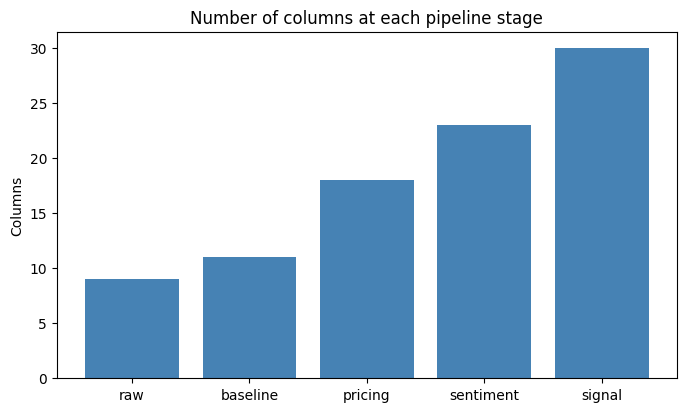

In [3]:
column_counts = [frame.shape[1] for _, frame in stages]
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 4.5))
plt.bar([name for name, _ in stages], column_counts, color="steelblue")
plt.title("Number of columns at each pipeline stage")
plt.ylabel("Columns")
plt.show()


The identity checks confirm that all five stages describe the same 467 facilities, so
nothing is silently lost or duplicated as the pipeline runs. The column count grows from
nine at the raw stage to thirty by the signal stage, with baseline adding a cleaned name and
category, pricing adding zone and rate fields, sentiment adding review based scores, and
signal adding the live traffic reading. Reading these five files as one growing table,
rather than five independent ones, is the right way to think about this part of the
project.


### How complete each added layer actually is

Adding a column is not the same as filling it in. It is worth checking how much of each
newly added layer is genuinely populated rather than left blank.


In [4]:
checks = {
    "pricing_source resolved": (pricing["pricing_source"] != "unresolved_estimate").mean(),
    "sentiment data available": (sentiment["sentiment_data_source"] != "unavailable_no_review_data").mean(),
    "traffic reading available": signal["traffic_delay_index"].notna().mean(),
}
for label, value in checks.items():
    print(f"{label}: {value:.1%}")


pricing_source resolved: 32.8%
sentiment data available: 0.0%
traffic reading available: 100.0%


Pricing is resolved for a minority of facilities, most fall back to the documented
estimate rather than a confirmed rate. Sentiment is close to entirely empty, which matches
the project's own documentation that review data has not been collected yet. Traffic
readings are the most complete of the three, since that layer is fed by a live API rather
than manual research or review scraping.


## 4. Data Cleaning

Checking for missing values, duplicates and obviously wrong values before drawing any
conclusions from the data.


In [5]:
raw.isnull().mean().round(2) * 100


osm_id              0.0
facility_name       0.0
latitude            0.0
longitude           0.0
parking_type        0.0
fee                 0.0
capacity           99.0
operating_hours     0.0
access              0.0
dtype: float64

Fee, capacity and operating hours are missing for most rows at the raw stage, which is
expected since OpenStreetMap volunteers rarely tag every field for every facility. Name and
location are essentially complete, which matters since those two are what everything else
in the pipeline is built on.


In [6]:
dupe_mask = raw.duplicated(subset=["osm_id"], keep=False)
print("duplicate facility ids in raw:", dupe_mask.sum())


duplicate facility ids in raw: 0


No duplicate facility ids appear in the raw pull, so each row genuinely represents one
distinct location rather than the same spot counted twice.


## 5. Exploratory Data Analysis

### On street versus off street

Category is assigned at the baseline stage, splitting facilities into on street spots along
a road and off street lots with their own dedicated space.


In [7]:
baseline["category"].value_counts()


category
Off-Street / Dedicated Lot    372
On-Street                      95
Name: count, dtype: int64

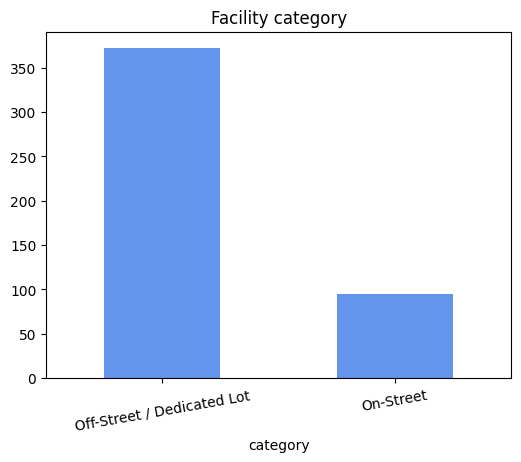

In [8]:
plt.figure(figsize=(6, 4.5))
baseline["category"].value_counts().plot(kind="bar", color="cornflowerblue")
plt.title("Facility category")
plt.xticks(rotation=10)
plt.show()


Off street lots make up the large majority of the 467 facilities, with on street spots
forming a smaller share. This matters for the project's scope, since the actual prediction
target only applies to the on street subset, which is a fraction of everything collected.


### Pricing patterns

Looking at where a real rate exists versus where the pipeline had to fall back to an
estimate.


In [9]:
pricing["pricing_source"].value_counts()


pricing_source
unresolved_estimate                314
NCCG_official_on_street             95
resolved_institutional_non_NCCG     35
resolved_private_non_NCCG           23
Name: count, dtype: int64

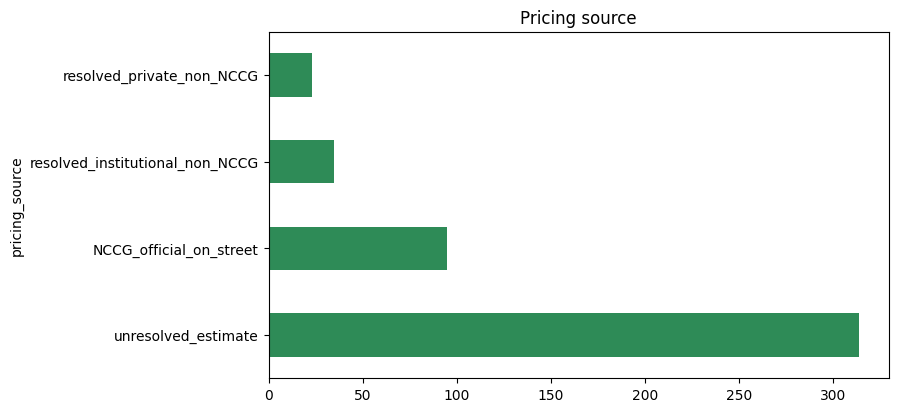

In [10]:
plt.figure(figsize=(8, 4.5))
pricing["pricing_source"].value_counts().plot(kind="barh", color="seagreen")
plt.title("Pricing source")
plt.show()


Most facilities carry the unresolved estimate label rather than a confirmed rate. Only
the subset with a real published Nairobi City County rate, the same subset that ends up in
the on street file, has genuinely verified pricing behind it.


### The on street detail file

This file holds the richest information but only for the smaller, verified on street
subset. Zone tells us roughly where in the city a facility sits.


In [11]:
onstreet["zone"].value_counts()


zone
Zone I     69
Zone II    26
Name: count, dtype: int64

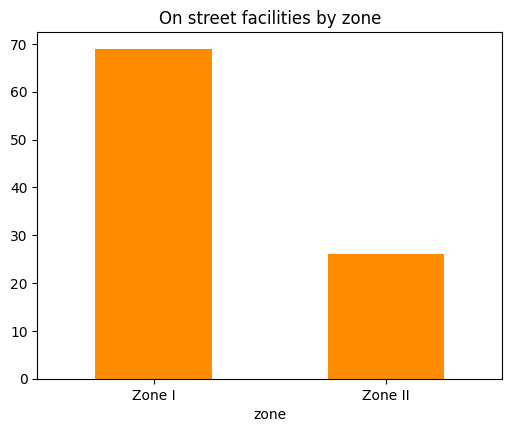

In [12]:
plt.figure(figsize=(6, 4.5))
onstreet["zone"].value_counts().plot(kind="bar", color="darkorange")
plt.title("On street facilities by zone")
plt.xticks(rotation=0)
plt.show()


Zone I holds most of the on street facilities in this file, consistent with it
covering the denser, more central part of the city where on street parking is more common
in the first place.


In [13]:
onstreet["validation_status"].value_counts()


validation_status
no_ground_truth_reference_available                     74
historical_reference_available_not_facility_specific    21
Name: count, dtype: int64

The majority of on street facilities have no ground truth reference of any kind. A
smaller group has a historical reference available, but even that reference is not specific
to the individual facility, it comes from a citywide survey rather than a direct
measurement of that exact spot.


### The live traffic log

Unlike the other files, this one grows over time as the collection script runs.


In [14]:
traffic_log["collected_at"] = pd.to_datetime(traffic_log["collected_at"])
print("rows:", len(traffic_log))
print("earliest reading:", traffic_log["collected_at"].min())
print("latest reading:", traffic_log["collected_at"].max())
print("distinct days covered:", traffic_log["collected_at"].dt.date.nunique())
print(traffic_log["is_weekend"].value_counts())


rows: 1063
earliest reading: 2026-08-26 10:11:38
latest reading: 2026-08-27 18:27:09
distinct days covered: 2
is_weekend
0    1063
Name: count, dtype: int64


The log currently spans only a couple of days and has not yet caught a weekend
reading. That means any comparison between weekday and weekend behaviour is not possible
with the data as it stands today, and would need several more days of continuous collection
before it becomes meaningful.


In [15]:
traffic_log["availability_label"].value_counts()


availability_label
insufficient_history    571
typical                 332
quieter_than_usual       86
busier_than_usual        74
Name: count, dtype: int64

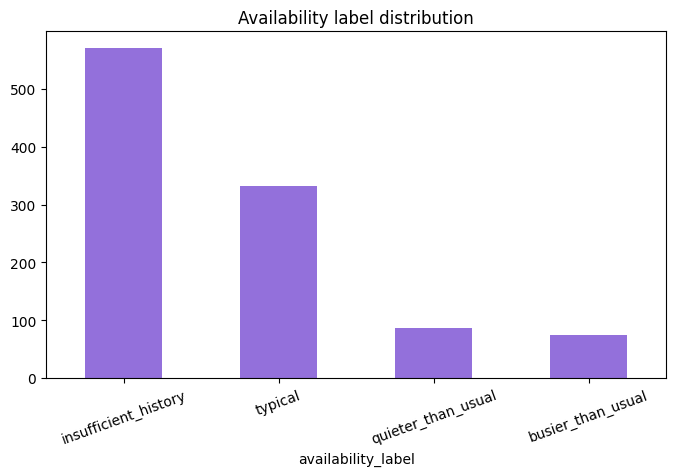

In [16]:
plt.figure(figsize=(8, 4.5))
traffic_log["availability_label"].value_counts().plot(kind="bar", color="mediumpurple")
plt.title("Availability label distribution")
plt.xticks(rotation=20)
plt.show()


This label is the project's actual delivered prediction, built by comparing each
reading against a facility's own historical baseline rather than against any absolute
occupancy figure. A large share of readings still fall into the insufficient history
category, meaning the system has not yet accumulated enough past readings at that facility
and hour to judge whether the current one is normal. Of the readings that do have enough
history, typical is the most common outcome, with busier and quieter than usual making up
smaller groups on either side.


### The ground truth file

This is the one file meant to hold real, physically observed occupancy counts rather than
anything derived from traffic data.


In [17]:
print("rows in spotcheck:", len(spotcheck))
spotcheck.head()


rows in spotcheck: 0


,location_id,facility_name,latitude,longitude,observed_datetime,observed_total_bays,observed_occupied_bays,observed_occupancy_pct,observer,notes


The file currently holds no rows. The project's own documentation notes that an
earlier script had been overwriting this file with traffic derived numbers relabelled as
ground truth, and that script has since been removed, leaving only genuinely recovered
field observations in its place. Right now that means there is no independent ground truth
at all to check the traffic based predictions against. This is the single most important
limitation to carry into any presentation of this data, since every downstream calibration
depends on this file eventually holding real entries again.


## Summary

The 467 raw facilities carry through five pipeline stages without any being lost, gaining
category, pricing, sentiment and traffic fields along the way. Off street lots outnumber on
street ones by a wide margin, and only on street facilities are in scope for the actual
prediction task. Pricing is confirmed for a minority of facilities and estimated for the
rest, while sentiment data has barely been collected. The on street file shows Zone I
holding most of the coverage, with very little historical reference to lean on for
validation. The traffic log is growing but still covers only a couple of days with no
weekend reading yet, and its availability label shows that most readings still lack enough
history to be judged as normal or unusual. The ground truth spot check file is currently
empty, which means the project's traffic based predictions cannot yet be checked against
any real, independently observed occupancy count.
